In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set parameters for the grid
grid_size = 1000
correlation_length = 25  # Adjust this for higher/lower correlation

# Generate the spatial correlation matrix
def spatial_correlation_matrix(size, correlation_length):
    x = np.linspace(0, 1, size)
    y = np.linspace(0, 1, size)
    X1, Y1 = np.meshgrid(x, y)
    d = np.sqrt((X1 - X1.T) ** 2 + (Y1 - Y1.T) ** 2)
    correlation_matrix = np.exp(-d / correlation_length)
    return correlation_matrix

# Generate tree presence/absence grid
def generate_tree_grid(size, correlation_length, threshold=0.5):
    correlation_matrix = spatial_correlation_matrix(size, correlation_length)
    sample = np.random.multivariate_normal(np.zeros(size**2), correlation_matrix)
    presence_absence_grid = (sample > norm.ppf(threshold)).reshape(size, size)
    return presence_absence_grid

# Create the grid
tree_grid = generate_tree_grid(grid_size, correlation_length)

# Visualization
plt.figure(figsize=(10, 10))
plt.imshow(tree_grid, cmap='Greens')
plt.title('Presence (Green) / Absence (White) of Trees')
plt.axis('off')
plt.show()


ValueError: mean and cov must have same length

In [6]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 1.7 MB/s eta 0:00:00m eta 0:00:010:00:02


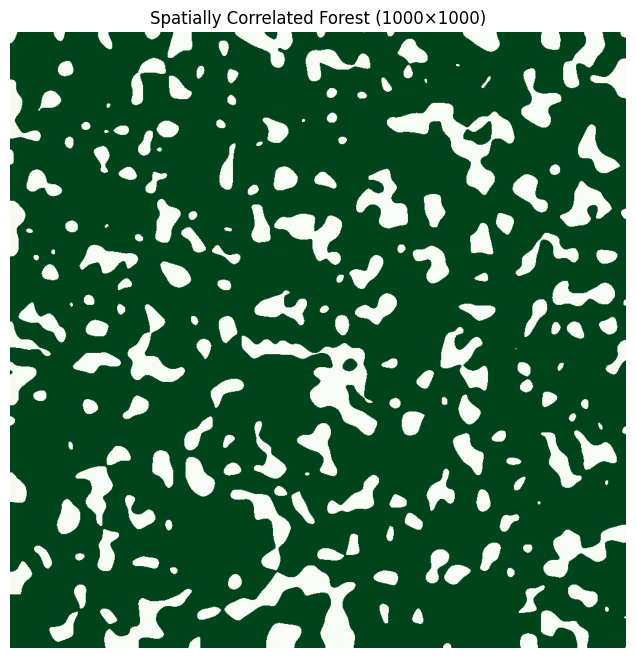

In [14]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

# Parameters
N = 1000                     # grid size
correlation_length = 10      # larger = smoother, more clustered
tree_density = 0.8           # fraction of cells with trees

# 1. Generate white noise
noise = np.random.randn(N, N)

# 2. Smooth it to introduce spatial correlation
field = gaussian_filter(noise, sigma=correlation_length)

# 3. Convert to binary using a quantile threshold
threshold = np.quantile(field, 1 - tree_density)
forest = (field > threshold).astype(int)

# 4. Plot
plt.figure(figsize=(8, 8))
plt.imshow(forest, cmap="Greens")
plt.title("Spatially Correlated Forest (1000×1000)")
plt.axis("off")
plt.show()


In [9]:
forest.shape

(1000, 1000)

In [15]:
forest

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 0],
       [1, 1, 1, ..., 1, 1, 0]], shape=(1000, 1000))

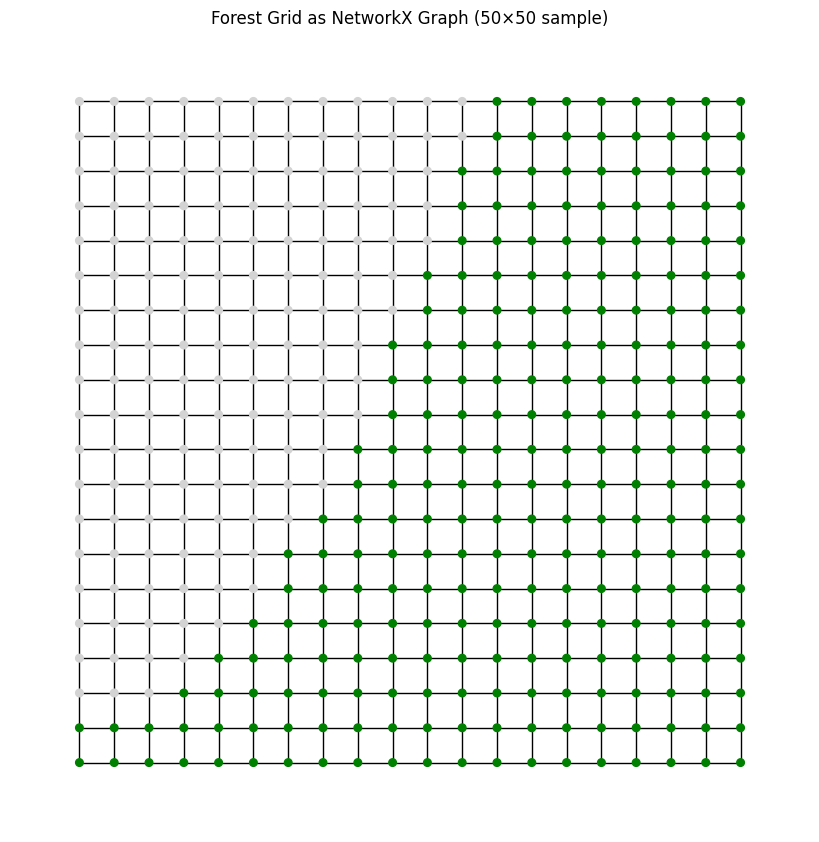

In [20]:
import matplotlib.pyplot as plt
import networkx as nx

# choose region to visualize (e.g., top-left 50x50)
size = 20
patch = forest[:size, :size]

# Build small graph
Gsmall = nx.grid_2d_graph(size, size)

# node colors: green for trees, gray for empty
colors = ["green" if patch[i, j] == 1 else "lightgray"
          for (i, j) in Gsmall.nodes()]

pos = {(i, j): (j, -i) for (i, j) in Gsmall.nodes()}  # keep grid layout

plt.figure(figsize=(8, 8))
nx.draw(Gsmall, pos=pos, node_size=30, node_color=colors, edge_color="black")
plt.title("Forest Grid as NetworkX Graph (50×50 sample)")
plt.axis("off")
plt.show()


In [17]:
!pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 4.0 MB/s eta 0:00:004.1 MB/s eta 0:00:01


In [21]:
import networkx as nx
import numpy as np

# forest is your 1000x1000 binary array (1 = tree, 0 = empty)

N = forest.shape[0]
G = nx.Graph()

# Add nodes for each tree
for i in range(N):
    for j in range(N):
        if forest[i, j] == 1:
            G.add_node((i, j))

# Add edges between adjacent trees (4-neighbors)
for i in range(N):
    for j in range(N):
        if forest[i, j] == 1:
            if i+1 < N and forest[i+1, j] == 1:
                G.add_edge((i, j), (i+1, j))
            if j+1 < N and forest[i, j+1] == 1:
                G.add_edge((i, j), (i, j+1))


In [22]:
degrees = np.array([deg for _, deg in G.degree()])

mean_degree = degrees.mean()
var_degree  = degrees.var()

print("Mean degree:", mean_degree)
print("Variance of degree:", var_degree)


Mean degree: 3.957215
Variance of degree: 0.06274944377499998
